# Esperimento di Millikan - Carica elettrica dell’elettrone
Giovanni Nicola D'Aloisio, n. di matricola 494722; prova svolta il 19 maggio 2021.

---

## Introduzione
<p align="justify">L'elettrone è una particella subatomica dotata di carica elettrica negativa, detta carica elettrica fondamentale, che caratterizza sensibilmente la natura degli atomi nonché le proprietà chimiche. Per dimostrare che ogni altra carica elettrica è multiplo della carica fondamentale $e$ si può nebulizzare un olio minerale in una camera compresa tra le piastre di un condensatore piano, avente campo elettrico variabile; assumendo le particelle di olio come sferiche, esse accelerano nella direzione della risultante della forza elettrica e gravitazionale, permettendo di calcolarne la velocità finale e, quindi, la carica elettrica accumulata su ogni goccia. Tale metodo si deve a R. Millikan, che lo realizzò per primo nel 1909.

## Scopi della prova
Gli obiettivi di questa prova sono:
* Misurare la carica dell’elettrone con l’apparato di Millikan;
* Verificare la natura quantizzata della carica elettrica.

## Apparato sperimentale
Per raggiungere gli obiettivi della prova si dispone di:
* Un nebulizzatore contenente olio minerale;
* Una camera cilindrica contenente aria, avente una parte bassa collegata a quella alta mediante un piccolo foro;
* Un condensatore piano, con le armature fissate agli estremi della camera di nebulizzazione più bassa, per ionizzare le goccioline di olio;
* Un microscopio con lampada, per visualizzare la caduta e la risalita delle goccioline di olio all'interno della camera;
* Un generatore di frequenze, per regolare il potenziale del campo elettrico;
* Un selettore, per regolare il campo elettrico.

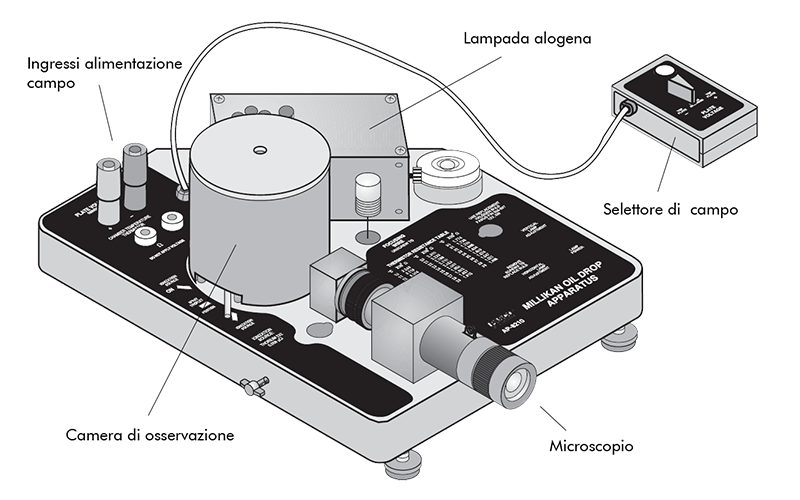

## Procedura
<p align="justify">Dopo aver impostato il campo elettrico dal generatore di frequenze, si immette attraverso un piccolo foro l'olio minerale nebulizzato e si osservano tante minuscole goccioline di olio tra le piastre del condensatore, per il momento scarico. Applicando il campo elettrico con verso opposto a quello gravitazionale, si osserva che tutte le goccioline si muovono verso l'alto, con accelerazioni più o meno differenti.

<p align="justify">Si fissa una gocciolina particolare, e se ne misurano i tempi di caduta libera e di risalita (quest'ultima sotto l'azione del campo elettrico) per almeno 3 volte, ripetendo lo stesso procedimento con più gocce. Si noti che se le gocce sono molto piccole, sono inosservabili a causa del moto browniano (ovvero il moto casuale delle singole particelle sospese in un fluido, dovuto a collisioni con le molecole del fluido stesso), mentre se le gocce sono molto grandi il tempo di caduta libera è molto più grande di quello di risalita in presenza di campo elettrico. 

<p align="justify">Per ogni goccia si calcolano dunque tempo medio e velocità media di caduta e risalita sapendo che $\bar v = {\Delta s \over \Delta t}$, con le relative incertezze.

<p align="justify">Approssimando ogni goccia a una sfera, dalla legge di Stokes si ricava il raggio $a$ corrispondente:

> $a = \sqrt\frac{9 \eta v_f}{2 \rho g}$

<p align="justify">Tale grandezza è confrontabile con il libero cammino medio delle particelle di aria, e il valore della viscosità deve essere corretto mediante la cosiddetta correzione di Cunningham, definita come segue:

> $\eta_\text{eff} = \eta \Big( \frac{1}{1+{b \over pa}} \Big) \quad $ con $ \quad b = 0.00824 \text{ N m}^{-1}$

<p align="justify">Con i raggi calcolati con la viscosità corretta, si calcola la massa della singola goccia d'olio:

> $m = \rho {4 \pi \over 3} a^3$

<p align="justify">Infine, dalla risultante delle forze agenti sulla goccia risulta che la carica su di essa vale:

> $q = {mg(v_f + v_r) \over E v_f} \quad$ con $\quad E={V \over d}$

<p align="justify">Cioé un multiplo della carica fondamentale $e$.

## Analisi dei dati sperimentali
In questa sezione sono riportati gli script in Python utilizzati per l'analisi dei dati sperimentali, con i relativi risultati.

In [12]:
# Librerie di lavoro
 
import numpy as np
from matplotlib import pyplot as plt 
from scipy.optimize import curve_fit 
from scipy import odr, constants
import json

# Dati ambientali (S.I.)
 
ro_oil = 886                                            # Densità dell'olio (tabulato)
eta_air = 1.680e-5                                      # Viscosità dell'aria a t_air (tabulato) [Poise]
b = 0.00824                                             # Costante per la correzione di Cunningham (tabulato)
 
t_air = 302                                             # Temperatura ambientale
t_air_err = 1                                           # Errore assoluto sulla temperatura ambientale
t_air_rel = t_air_err/t_air                             # Errore assoluto sulla temperatura ambientale
 
d_capacitor = 0.0075                                    # Distanza tra le armature del condensatore
d_capacitor_err = 0.0001                                # Errore assoluto sulla distanza precedente
d_capacitor_rel = d_capacitor_err/d_capacitor           # Errore assoluto sulla distanza precedente
 
p_air = 101900                                          # Pressione barometrica
p_air_err = 5                                           # Errore assoluto sulla pressione barometrica
p_air_rel = p_air_err/p_air                             # Errore relativo sulla pressione barometrica
 
deltaV = 400                                            # Tensione del campo elettrico
deltaV_err = 1                                          # Errore assoluto sulla tensione
deltaV_rel = deltaV_err/deltaV                          # Errore relativo sulla tensione

d_gocce = 0.0010                                        # Distanza percorsa da ciascuna goccia
d_gocce_err = 0.0001                                    # Errore assoluto sulla distanza percorsa
d_gocce_rel = d_gocce/d_gocce_err                       # Errore relativo sulla distanza percorsa

t_err = 0.01                                            # Errore assoluto sulle misure di tempo
 
# dati_n sono liste di liste [t_1, t_2] dove t_1 = tempo di caduta libera e t_2 = tempo di risalita in E, per gocce di olio diverse
 
dati_1 = [[19.23, 17.86, 20.16, 17.89, 18.69], [9.37, 15.91, 15.86, 7.27, 7.50]]
dati_2 = [[35.79, 35.48, 35.25, 35.4, 35.68, 34.87, 36.57,33.94], [31.63, 6.78, 4.95, 4.7, 4.93, 11.04, 11.27, 7.23]]
dati_3 = [[6.62, 6.33, 6.29], [21.59, 21.41, 21.99]]
dati_4 = [[44.02, 38.75, 40.89, 45.75, 44.37, 38.79], [9.27, 9.99, 9.93, 6.16, 3.2, 3.25]]
dati_5 = [[28.91, 32.73, 28.73, 29.92, 29.17], [44.6, 8.08, 7.62, 3.58, 3.7]]
 
data = [dati_1, dati_2, dati_3, dati_4, dati_5]

# Tempi - Array del tipo [[tempo medio caduta,incertezza],[tempo medio risalita,incertezza]]
 
time = []

for i in data:
  j = [[np.mean(i[0]), np.std(i[0],ddof=1)/np.sqrt(len(i[0]))], [np.mean(i[1]), np.std(i[1],ddof=1)/np.sqrt(len(i[0]))]]
  time.append(j)

time = np.array(time)

# Velocita` - Array del tipo [[velocità media caduta,incertezza],[velocità media risalita,incertezza]]

speed = []

for k in time:
  x = []
  for i in k:
    j = [d_gocce/i[0], (d_gocce/i[0])*((d_gocce_err/d_gocce)+((t_err+i[1])/i[0]))]
    x.append(j)
  speed.append(x)

speed = np.array(speed)

# Raggi secondo Cunningham - Array del tipo [raggio della goccia, incertezza]

radius = []

for i in speed:
    j = [np.sqrt((b/(2*p_air))**2+(9*eta_air*(i[0])[0]/(2*ro_oil*constants.g)))-(b/(2*p_air)), p_air_err*((b/(2*p_air**2))-(b**2/(4*p_air**3*np.sqrt((b**2/(4*p_air**2))+(9*eta_air*(i[0])[0]/(2*ro_oil*constants.g)))))) + (i[0])[1]*9*eta_air/(4*constants.g*ro_oil*np.sqrt(((8.2e-3)**2/(4*p_air**2))+(9*eta_air*(i[0])[0]/(2*ro_oil*constants.g))))]
    radius.append(j)

radius = np.array(radius)

# Masse - Array del tipo [massa della goccia, incertezza]

mass = []

for i in radius:
    j = [ro_oil*4*np.pi*(i[0]**3)/3, 4*np.pi*ro_oil*i[0]**2*i[1]]
    mass.append(j)

mass = np.array(mass)

# Cariche - Array del tipo [carica della goccia, incertezza]

charge = np.array([[(mass[0])[0]*constants.g*(((speed[0])[0])[0]+((speed[0])[1])[0])*d_capacitor/(deltaV*(((speed[0])[0])[0])), (((mass[0])[1]/(mass[0])[0])+(((speed[0])[0])[1]+((speed[0])[1])[1])/(((speed[0])[0])[0]+((speed[0])[1])[0])+deltaV_rel+d_capacitor_rel+(((speed[0])[0])[1]/((speed[0])[0])[0]))*((mass[0])[0]*constants.g*(((speed[0])[0])[0]+((speed[0])[1])[0])*d_capacitor/(deltaV*((speed[0])[0])[0]))], [(mass[1])[0]*constants.g*(((speed[1])[0])[0]+((speed[1])[1])[0])*d_capacitor/(deltaV*(((speed[1])[0])[0])), (((mass[1])[1]/(mass[0])[0])+(((speed[1])[0])[1]+((speed[1])[1])[1])/(((speed[1])[0])[0]+((speed[1])[1])[0])+deltaV_rel+d_capacitor_rel+(((speed[1])[0])[1]/((speed[1])[0])[0]))*((mass[1])[0]*constants.g*(((speed[1])[0])[0]+((speed[1])[1])[0])*d_capacitor/(deltaV*((speed[1])[0])[0]))], [(mass[2])[0]*constants.g*(((speed[2])[0])[0]+((speed[2])[1])[0])*d_capacitor/(deltaV*(((speed[2])[0])[0])), (((mass[2])[1]/(mass[0])[0])+(((speed[2])[0])[1]+((speed[2])[1])[1])/(((speed[2])[0])[0]+((speed[2])[1])[0])+deltaV_rel+d_capacitor_rel+(((speed[2])[0])[1]/((speed[2])[0])[0]))*((mass[2])[0]*constants.g*(((speed[2])[0])[0]+((speed[2])[1])[0])*d_capacitor/(deltaV*((speed[2])[0])[0]))], [(mass[3])[0]*constants.g*(((speed[3])[0])[0]+((speed[3])[1])[0])*d_capacitor/(deltaV*(((speed[3])[0])[0])), (((mass[3])[1]/(mass[0])[0])+(((speed[3])[0])[1]+((speed[3])[1])[1])/(((speed[3])[0])[0]+((speed[3])[1])[0])+deltaV_rel+d_capacitor_rel+(((speed[3])[0])[1]/((speed[3])[0])[0]))*((mass[3])[0]*constants.g*(((speed[3])[0])[0]+((speed[3])[1])[0])*d_capacitor/(deltaV*((speed[3])[0])[0]))], [(mass[4])[0]*constants.g*(((speed[4])[0])[0]+((speed[4])[1])[0])*d_capacitor/(deltaV*(((speed[4])[0])[0])), (((mass[4])[1]/(mass[0])[0])+(((speed[4])[0])[1]+((speed[4])[1])[1])/(((speed[4])[0])[0]+((speed[4])[1])[0])+deltaV_rel+d_capacitor_rel+(((speed[4])[0])[1]/((speed[4])[0])[0]))*((mass[4])[0]*constants.g*(((speed[4])[0])[0]+((speed[4])[1])[0])*d_capacitor/(deltaV*((speed[4])[0])[0]))]])

print("  q [C] \t δq [C] \n" + str(charge) + "\n")

print("  q [e]      δq [e] \n" + str(charge/constants.e) + "\n")

  q [C] 	 δq [C] 
[[4.82913100e-19 2.67902750e-19]
 [2.88794176e-19 1.52577775e-19]
 [1.25942741e-18 1.55457760e-18]
 [3.45980764e-19 1.62775796e-19]
 [2.74939337e-19 2.04470203e-19]]

  q [e]      δq [e] 
[[3.01410649 1.67211744]
 [1.80251147 0.95231557]
 [7.8607276  9.70291019]
 [2.15944208 1.01596661]
 [1.71603636 1.27620262]]



## Discussione dei risultati e conclusioni
<p align="justify">Dall'analisi dei dati sperimentali sono stati trovati i seguenti valori di carica elettrica:

* $(4.8 \pm 2.7) \times 10^{-19} \ C \quad \simeq \quad 3 \ e$
* $(2.9 \pm 1.5) \times 10^{-19} \ C \quad \simeq \quad 2 \ e$
* $(1.3 \pm 1.6) \times 10^{-18} \ C \quad \simeq \quad 8 \ e$
* $(3.5 \pm 1.6) \times 10^{-19} \ C \quad \simeq \quad 2 \ e$
* $(2.7 \pm 2.0) \times 10^{-19} \ C \quad \simeq \quad 2 \ e$

<p align="justify">È evidente che tre cariche presentano lo stesso valore; ciò deriva dal fatto che, sotto le stesse condizioni ambientali, i tempi di caduta e risalita sono piuttosto simili.

<p align="justify">La terza goccia, invece, è dotata di una carica sensibilmente maggiore rispetto alle altre. Quello che appare come uno strano risultato, invece, deriva da un problema già sperimentato dal Millikan nel 1909. Essendo molto pesante, si osserva un forte squilibrio tra la velocità di caduta libera e la velocità di risalita in campo elettrico:

> $v_\text{caduta} = (1.6 \pm 0.2) \times 10^{-4} \text{ m/s} \quad \cdots \quad v_\text{risalita} = (4.6 \pm 0.5) \times 10^{-5} \text{ m/s}$

<p align="justify">Questa nota instabilità, inoltre, ha fatto sì che venisse persa dalla visuale dopo appena tre coppie di misura, dimostrando che l'esperimento è possibile solo con gocce di dimensioni sufficientemente bilanciate.

<p align="justify">Per i risultati ottenuti, si considerano allora raggiunti tutti gli obiettivi della prova.